# Compounding Fire Risk — LA County
### Fire Station Coverage (TDA) + Hospital Access + Population Density + Hydrant Density

The **primary analysis** is the Vietoris–Rips persistent homology of the LA County fire-station
network (same methodology as *tda_fire_stations_ph.ipynb* Step 9). For each of the 272 named
neighbourhoods, three **compounding risk factors** are layered on top of the station
coverage-gap score to produce a single composite at-risk ranking.

| Layer | Metric | Direction | Weight |
|---|---|---|---|
| Primary (TDA) | Station coverage-gap score | gap up = risk up | 0.35 |
| Compounding 1 | Distance to nearest hospital (km) | distance up = risk up | 0.25 |
| Compounding 2 | Population density (people / km2) | density up = impact up | 0.20 |
| Compounding 3 | Hydrant density (hydrants / km2) | density down = risk up | 0.20 |

**Composite score:**
```
composite_risk = 0.35 * norm(coverage_gap)
               + 0.25 * norm(hosp_dist)
               + 0.20 * norm(pop_density)
               + 0.20 * (1 - norm(hydrant_density))
```
where `norm(x)` is min-max normalisation over all 272 neighbourhoods.

In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
import gudhi
import warnings
warnings.filterwarnings("ignore")

DATA = "../../data/"
CRS  = "EPSG:32611"          # UTM Zone 11N — metres

# TDA parameters — kept identical to tda_fire_stations_ph.ipynb
RIPS_MAX_M         = 25_000  # Rips ceiling: 25 km
H1_SIG_THRESHOLD_M =  3_000  # significant void: persistence >= 3 km
EVAL_RADIUS_M      =  8_000  # neighbourhood station search radius: 8 km
W_DIST    = 0.50
W_BETA1   = 0.30
W_DENSITY = 0.20

# Compounding-risk weights (new)
W_STATION  = 0.35
W_HOSPITAL = 0.25
W_POP      = 0.20
W_HYDRANT  = 0.20

## 1. Load & Project Data

In [15]:
stations  = gpd.read_file(DATA + "all_stations.geojson")
county    = gpd.read_file(DATA + "la_county_svi.geojson")
hydrants  = gpd.read_file(DATA + "Fire_Hydrants_(DWP).geojson")
hospitals = gpd.read_file(DATA + "Hospitals_and_Medical_Centers.geojson")
la_bdry   = gpd.read_file(DATA + "la_county.geojson")

stations_proj  = stations.to_crs(CRS)
county_proj    = county.to_crs(CRS)
hydrants_proj  = hydrants.to_crs(CRS)
hospitals_proj = hospitals.to_crs(CRS)
la_proj        = la_bdry.to_crs(CRS)

# Clip all point layers to county boundary
stations_proj  = gpd.clip(stations_proj,  la_proj).reset_index(drop=True)
hydrants_proj  = gpd.clip(hydrants_proj,  la_proj).reset_index(drop=True)
hospitals_proj = gpd.clip(hospitals_proj, la_proj).reset_index(drop=True)

coords_m        = np.array([[g.x, g.y] for g in stations_proj.geometry])
hospital_coords = np.array([[g.x, g.y] for g in hospitals_proj.geometry])

print(f"Fire stations : {len(stations_proj)}")
print(f"Hospitals     : {len(hospitals_proj)}")
print(f"Fire hydrants : {len(hydrants_proj)}")
print(f"Neighbourhoods: {len(county_proj)}")

Fire stations : 408
Hospitals     : 162
Fire hydrants : 59770
Neighbourhoods: 272


## 2. Fire Station TDA — Vietoris-Rips (Primary Analysis)

Build the Rips complex on all station coordinates and extract H0/H1 persistence pairs.
- **H0 pairs** represent connected components merging as the radius grows.
- **H1 pairs** represent coverage voids (loops in the station network) that appear and close.

In [16]:
rips = gudhi.RipsComplex(points=coords_m, max_edge_length=RIPS_MAX_M)
st   = rips.create_simplex_tree(max_dimension=2)
st.compute_persistence()

diag_rips = {"H0": [], "H0_inf": [], "H1": [], "H1_inf": []}
for dim, (birth, death) in st.persistence():
    key = f"H{dim}" + ("_inf" if np.isinf(death) else "")
    if key in diag_rips:
        diag_rips[key].append((birth, death))

print(f"H0 finite pairs   : {len(diag_rips['H0'])}")
print(f"H0 essential pairs: {len(diag_rips['H0_inf'])}")
print(f"H1 finite pairs   : {len(diag_rips['H1'])}")
print(f"H1 essential pairs: {len(diag_rips['H1_inf'])}")

H0 finite pairs   : 406
H0 essential pairs: 2
H1 finite pairs   : 146
H1 essential pairs: 0


In [17]:
h1_arr  = np.array(diag_rips["H1"])
h1_pers = h1_arr[:, 1] - h1_arr[:, 0]
sig_mask = h1_pers >= H1_SIG_THRESHOLD_M
sig_arr  = h1_arr[sig_mask]
sig_pers = h1_pers[sig_mask]

print(f"Significant H1 voids (persistence >= {H1_SIG_THRESHOLD_M/1000:.0f} km): {sig_mask.sum()}")
print(f"{'Birth (km)':>12}  {'Death (km)':>12}  {'Pers (km)':>10}")
print("-" * 40)
for (b, d), p in sorted(zip(sig_arr, sig_pers), key=lambda x: -x[1]):
    print(f"{b/1000:12.2f}  {d/1000:12.2f}  {p/1000:10.2f}")

Significant H1 voids (persistence >= 3 km): 3
  Birth (km)    Death (km)   Pers (km)
----------------------------------------
        8.11         12.53        4.42
        9.86         13.33        3.47
        3.34          6.80        3.47


## 3. Neighbourhood Coverage-Gap Score

Identical to Step 9 of *tda_fire_stations_ph.ipynb*. Produces `vuln_df` with a
`coverage_gap_score` in [0, 1] per neighbourhood (higher = worse coverage).

In [18]:
def min_max_scale(s):
    lo, hi = s.min(), s.max()
    return (s - lo) / (hi - lo) if hi > lo else s * 0


def score_neighborhoods(stations_gdf, county_gdf, coords, diag, radius=EVAL_RADIUS_M):
    records = []
    for _, hood in county_gdf.iterrows():
        c    = hood.geometry.centroid
        cxy  = np.array([c.x, c.y])
        dist = np.sqrt(((coords - cxy) ** 2).sum(axis=1))
        min_d   = dist.min()
        nidx    = dist.argmin()
        area    = hood.geometry.area / 1e6
        n_near  = int((dist <= radius).sum())
        density = n_near / max(area, 0.01)
        beta1   = sum(1 for b, d in diag["H1"] if b <= min_d <= d)
        records.append({
            "neighborhood"        : hood.get("name", "Unknown"),
            "area_km2"            : round(area, 2),
            "min_station_dist_km" : round(min_d / 1000, 3),
            "n_stations_8km"      : n_near,
            "station_density_km2" : round(density, 4),
            "local_beta1"         : beta1,
            "nearest_dept"        : stations_gdf.iloc[nidx]["department"],
        })
    df = pd.DataFrame(records)
    df["coverage_gap_score"] = (
        W_DIST    * min_max_scale(df["min_station_dist_km"]) +
        W_BETA1   * min_max_scale(df["local_beta1"]) +
        W_DENSITY * (1 - min_max_scale(df["station_density_km2"]))
    ).round(4)
    return df.sort_values("coverage_gap_score", ascending=False).reset_index(drop=True)


vuln_df = score_neighborhoods(stations_proj, county_proj, coords_m, diag_rips)
print("Top 10 by coverage gap score (TDA primary):")
print(vuln_df.head(10)[["neighborhood", "min_station_dist_km",
                         "n_stations_8km", "local_beta1",
                         "coverage_gap_score"]].to_string(index=False))

Top 10 by coverage gap score (TDA primary):
                         neighborhood  min_station_dist_km  n_stations_8km  local_beta1  coverage_gap_score
                               Avalon               42.790               0            0              0.7000
       Unincorporated Catalina Island               39.329               0            0              0.6595
                          Sun Village                3.500               2           52              0.5395
                            Brentwood                3.636              10           51              0.5343
                    South Diamond Bar                3.733               3           50              0.5299
Unincorporated Santa Susana Mountains                4.036               3           45              0.5057
                       North Whittier                3.410              15           47              0.5041
                    Pacific Palisades                4.062               4           42     

## 4. Compounding Risk Factors

Three additional metrics computed for every neighbourhood:

1. **Hospital distance** — nearest hospital to neighbourhood centroid (KD-Tree on projected coords)
2. **Population density** — resident population (`e_totpop` from SVI) divided by neighbourhood area
3. **Hydrant density** — fire hydrants per km2 via spatial join

In [19]:
# 4a. Nearest hospital distance (km) per neighbourhood centroid
hosp_tree     = cKDTree(hospital_coords)
centroids     = county_proj.geometry.centroid
centroid_xy   = np.array([[g.x, g.y] for g in centroids])
hosp_dists_m, hosp_idxs = hosp_tree.query(centroid_xy)

name_col = "Name" if "Name" in hospitals_proj.columns else "org_name"
hosp_df  = pd.DataFrame({
    "neighborhood"    : county_proj["name"].values,
    "hosp_dist_km"    : (hosp_dists_m / 1000).round(3),
    "nearest_hospital": hospitals_proj.iloc[hosp_idxs][name_col].values,
})

print("Neighbourhoods farthest from any hospital:")
print(hosp_df.nlargest(8, "hosp_dist_km")[["neighborhood", "hosp_dist_km",
                                            "nearest_hospital"]].to_string(index=False))

Neighbourhoods farthest from any hospital:
             neighborhood  hosp_dist_km                                  nearest_hospital
              Ridge Route        28.917              Henry Mayo Newhall Memorial Hospital
         Lake Los Angeles        28.561                  Palmdale Regional Medical Center
Southeast Antelope Valley        28.005                  Palmdale Regional Medical Center
              Lake Hughes        27.263                          Antelope Valley Hospital
Northeast Antelope Valley        26.836         Tarzana Family Medical Clinic - Lancaster
Northwest Antelope Valley        26.003                          Antelope Valley Hospital
             Green Valley        24.338                          Antelope Valley Hospital
                   Malibu        23.152 Kaiser Permanente - Woodland Hills Medical Center


In [7]:
# 4b. Population density (residents / km2) from SVI e_totpop
pop_df = county_proj[["name", "e_totpop", "geometry"]].copy()
pop_df["e_totpop"]       = pd.to_numeric(pop_df["e_totpop"], errors="coerce").fillna(0)
pop_df["area_km2"]       = pop_df.geometry.area / 1e6
pop_df["pop_density_km2"] = (pop_df["e_totpop"] / pop_df["area_km2"].clip(lower=0.01)).round(1)
pop_df = pop_df[["name", "e_totpop", "pop_density_km2"]].rename(
    columns={"name": "neighborhood", "e_totpop": "pop_total"}
)

print("Highest population density neighbourhoods:")
print(pop_df.nlargest(8, "pop_density_km2")[["neighborhood", "pop_total",
                                              "pop_density_km2"]].to_string(index=False))

Highest population density neighbourhoods:
       neighborhood  pop_total  pop_density_km2
           Westlake   115022.0          16622.1
          Koreatown    98943.0          14187.2
    Harvard Heights    24649.0          11765.3
         South Park    40430.0          11063.4
     East Hollywood    65393.0          10615.8
         Pico-Union    39672.0           9357.9
    Vermont-Slauson    34928.0           9350.9
Chesterfield Square    15057.0           9350.4


In [20]:
# 4c. Hydrant density (hydrants / km2) — spatial join assigns each hydrant to its neighbourhood
hydrant_join = gpd.sjoin(
    hydrants_proj[["geometry"]],
    county_proj[["name", "geometry"]],
    how="inner",
    predicate="within",
)
hydrant_counts = (
    hydrant_join.groupby("name").size().reset_index(name="hydrant_count")
)

area_lookup = county_proj.assign(
    area_km2=county_proj.geometry.area / 1e6
)[["name", "area_km2"]]

hyd_df = area_lookup.merge(hydrant_counts, on="name", how="left")
hyd_df["hydrant_count"]        = hyd_df["hydrant_count"].fillna(0).astype(int)
hyd_df["hydrant_density_km2"]  = (
    hyd_df["hydrant_count"] / hyd_df["area_km2"].clip(lower=0.01)
).round(2)
hyd_df = hyd_df.rename(columns={"name": "neighborhood"})[
    ["neighborhood", "hydrant_count", "hydrant_density_km2"]
]

print("Lowest hydrant density (highest suppression gap):")
print(hyd_df.nsmallest(8, "hydrant_density_km2")[["neighborhood", "hydrant_count",
                                                   "hydrant_density_km2"]].to_string(index=False))

Lowest hydrant density (highest suppression gap):
 neighborhood  hydrant_count  hydrant_density_km2
        Acton              0                  0.0
 Agoura Hills              0                  0.0
   Agua Dulce              0                  0.0
 Alondra Park              0                  0.0
     Altadena              0                  0.0
Angeles Crest              0                  0.0
      Arcadia              0                  0.0
      Artesia              0                  0.0


## 5. Combined At-Risk Table

Merge all four layers, min-max normalise each factor across the full 272-neighbourhood set,
then compute the composite risk score and assign risk tiers.

In [ ]:
merged = (
    vuln_df
    .merge(hosp_df, on="neighborhood", how="left")
    .merge(pop_df,  on="neighborhood", how="left")
    .merge(hyd_df,  on="neighborhood", how="left")
)

# Fill any unmatched rows with conservative defaults
merged["hosp_dist_km"]        = merged["hosp_dist_km"].fillna(merged["hosp_dist_km"].median())
merged["pop_density_km2"]     = merged["pop_density_km2"].fillna(0)
merged["hydrant_density_km2"] = merged["hydrant_density_km2"].fillna(0)

# Weighted normalised contributions (kept as separate columns for the bar chart)
merged["s_station"]  = W_STATION  * min_max_scale(merged["coverage_gap_score"])
merged["s_hospital"] = W_HOSPITAL * min_max_scale(merged["hosp_dist_km"])
merged["s_pop"]      = W_POP      * min_max_scale(merged["pop_density_km2"])
merged["s_hydrant"]  = W_HYDRANT  * (1 - min_max_scale(merged["hydrant_density_km2"]))

merged["composite_risk_score"] = (
    merged["s_station"] + merged["s_hospital"] + merged["s_pop"] + merged["s_hydrant"]
).round(4)

merged["risk_tier"] = pd.cut(
    merged["composite_risk_score"],
    bins=[0, 0.30, 0.45, 0.60, 1.01],
    labels=["Low", "Moderate", "High", "Critical"],
    right=False,
)

at_risk = merged.sort_values("composite_risk_score", ascending=False).reset_index(drop=True)

display_cols = [
    "neighborhood", "coverage_gap_score", "hosp_dist_km",
    "pop_density_km2", "hydrant_density_km2",
    "composite_risk_score", "risk_tier",
]
print("Top 20 At-Risk Neighbourhoods:")
print(at_risk.head(5)[display_cols].to_string(index=False))

Top 20 At-Risk Neighbourhoods:
                         neighborhood  coverage_gap_score  hosp_dist_km  pop_density_km2  hydrant_density_km2  composite_risk_score risk_tier
       Unincorporated Catalina Island              0.6595        11.023              0.0                 0.00                0.6239  Critical
            Southeast Antelope Valley              0.3662        28.005             13.9                 0.00                0.6209  Critical
                          Sun Village              0.5395        17.392              0.0                 0.00                0.6175  Critical
                          Ridge Route              0.3187        28.917             10.1                 0.00                0.6044  Critical
                    South Diamond Bar              0.5299        14.913            362.9                 0.00                0.5955      High
            Northeast Antelope Valley              0.3154        26.836             14.8                 0.00        

In [10]:
print("Risk Tier Distribution:")
print(at_risk["risk_tier"].value_counts().sort_index().to_string())

# Uncomment to export
# at_risk[display_cols].to_csv("../../results/compounding_risk_neighborhoods.csv", index=False)
# print("Saved to results/compounding_risk_neighborhoods.csv")

Risk Tier Distribution:
risk_tier
Low         104
Moderate    143
High         21
Critical      4


## 6. Visualisations

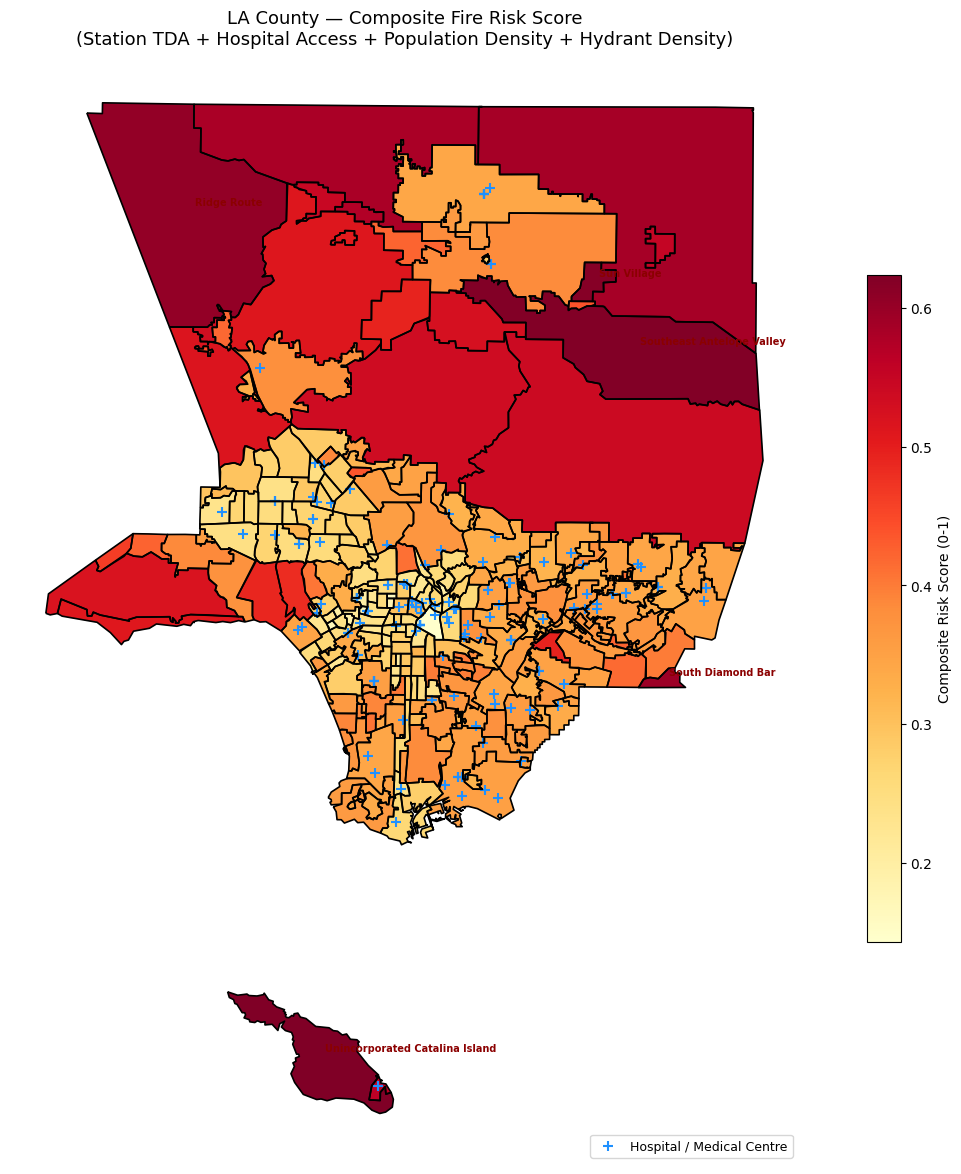

In [22]:
# 6a. Choropleth: composite risk score
map_df = county_proj.merge(
    at_risk[["neighborhood", "composite_risk_score", "risk_tier"]],
    left_on="name", right_on="neighborhood", how="left",
)

fig, ax = plt.subplots(figsize=(14, 12))
la_proj.boundary.plot(ax=ax, color="black", linewidth=1.2)
map_df.plot(
    column="composite_risk_score", ax=ax,
    cmap="YlOrRd", linewidth=0.3, edgecolor="grey",
    legend=True,
    legend_kwds={"label": "Composite Risk Score (0-1)", "shrink": 0.6},
    missing_kwds={"color": "lightgrey"},
)
# Overlay hospital locations
hospitals_proj.plot(ax=ax, color="dodgerblue", marker="+",
                    markersize=50, linewidths=1.5, label="Hospital / Medical Centre")
# Mark top 5 at-risk centroids
top5_names = at_risk.head(5)["neighborhood"].tolist()
top5_geom  = county_proj[county_proj["name"].isin(top5_names)].copy()
top5_geom["centroid"] = top5_geom.geometry.centroid
for _, row in top5_geom.iterrows():
    ax.annotate(
        row["name"], (row["centroid"].x, row["centroid"].y),
        fontsize=7, color="darkred", fontweight="bold",
        xytext=(4, 4), textcoords="offset points",
    )

ax.set_title(
    "LA County — Composite Fire Risk Score\n"
    "(Station TDA + Hospital Access + Population Density + Hydrant Density)",
    fontsize=13,
)
ax.set_axis_off()
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()